In [3]:
#importation de la bibliothèque et sa transformation en dataframe
import pandas as pd
df= pd.read_csv("/diabetes.csv")

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
#affichage des 5 première ligne par défaut
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [7]:
print(df.shape)

(768, 9)


In [8]:
print(df.columns)

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')


In [9]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


In [11]:
print(df.describe())

       Pregnancies     Glucose  ...         Age     Outcome
count   768.000000  768.000000  ...  768.000000  768.000000
mean      3.845052  120.894531  ...   33.240885    0.348958
std       3.369578   31.972618  ...   11.760232    0.476951
min       0.000000    0.000000  ...   21.000000    0.000000
25%       1.000000   99.000000  ...   24.000000    0.000000
50%       3.000000  117.000000  ...   29.000000    0.000000
75%       6.000000  140.250000  ...   41.000000    1.000000
max      17.000000  199.000000  ...   81.000000    1.000000

[8 rows x 9 columns]


In [31]:
#suppression des doublons
dup = df.duplicated().sum()
print(dup)

0


In [37]:
#changement des colonnes qui contiennent 0 en Nan
import numpy as np

cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df[cols] = df[cols].replace(0, np.nan)

In [38]:
df.fillna(df.mean(numeric_only=True), inplace=True)


In [39]:
#traitement des valeurs manquantes
v_m = df.isnull().sum()
print(v_m)

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [41]:
# Remplacer toutes les valeurs manquantes par la moyenne de chaque colonne
df = df.fillna(df.mean())
print(df)

     Pregnancies  Glucose  ...  Age  Outcome
0              6    148.0  ...   50        1
1              1     85.0  ...   31        0
2              8    183.0  ...   32        1
3              1     89.0  ...   21        0
4              0    137.0  ...   33        1
..           ...      ...  ...  ...      ...
763           10    101.0  ...   63        0
764            2    122.0  ...   27        0
765            5    121.0  ...   30        0
766            1    126.0  ...   47        1
767            1     93.0  ...   23        0

[768 rows x 9 columns]


In [42]:
# Méthode IQR
for col in df.select_dtypes(include=['float64','int64']).columns: #sélectionne uniquement les colonnes numériques.
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

In [43]:
for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

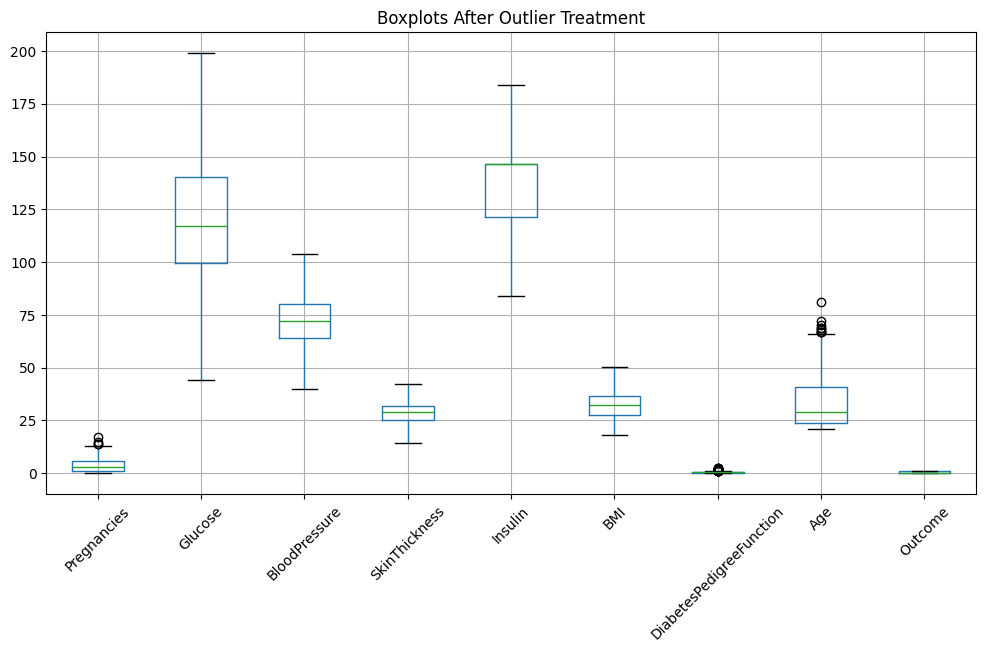

In [44]:
import matplotlib.pyplot  as plt
df.boxplot(figsize=(12,6))
plt.xticks(rotation=45)
plt.title("Boxplots After Outlier Treatment")
plt.show()

In [45]:
#séparation du dataset , features and target
feature_cols = ['Pregnancies',"Glucose" ,"BloodPressure", "SkinThickness",'Insulin', 'BMI', 'DiabetesPedigreeFunction','Age']
X = df[feature_cols]
Y= df["Outcome"]

In [46]:
from sklearn.model_selection import train_test_split
X_train , X_test , Y_train , Y_test = train_test_split(X, Y ,  test_size= 0.3 , random_state= 1  )

In [47]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [48]:
#importation de la classe
from sklearn.linear_model import LogisticRegression
# instantiate the model (using the default parameters)
logreg = LogisticRegression(random_state=16) #. Il estime la probabilité qu’une observation appartienne à une classe donnée en utilisant une fonction logistique (sigmoïde).

In [49]:
logreg.fit(X_train,Y_train)

LogisticRegression(random_state=16)

In [50]:
y_pred = logreg.predict(X_test)
print(y_pred)

[0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 1 0 1 0
 0 0 1 0 0 0 0 0 0 1 1 0 0 0 0 1 0 1 0 0 0 0 0 1 0 1 0 1 0 1 0 1 1 1 1 1 0
 1 0 1 0 0 1 1 0 0 0 0 1 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0
 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0 0 1 0 0 1 1 1 0 0
 0 0 0 1 1 0 1 1 0 0 0 0 1 1 0 0 0 0 0 1 1 1 1 1 0 0 1 0 1 0 0 0 1 1 0 1 0
 0 0 1 0 0 0 0 0 0 1 0 0 0 0 1 1 0 0 0 1 1 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0
 0 1 0 0 0 0 0 1 0]


In [51]:
from sklearn.metrics import accuracy_score
y_pred = logreg.predict(X_test)
print(accuracy_score(Y_test,y_pred))

0.7965367965367965


In [52]:
from sklearn.metrics import confusion_matrix
confusion_matrix(Y_test,y_pred)

array([[132,  14],
       [ 33,  52]])

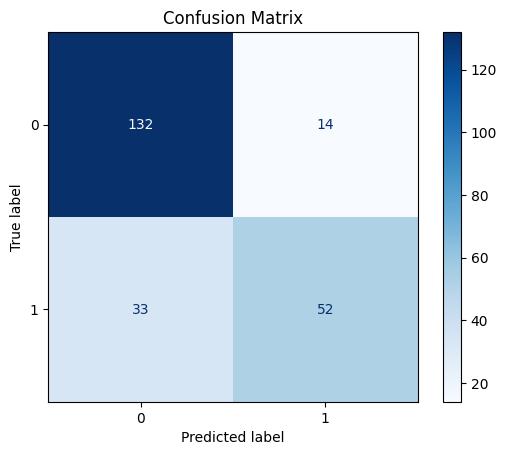

In [54]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(Y_test, y_pred, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [53]:
from sklearn.metrics import classification_report
print(classification_report(Y_test,y_pred))

              precision    recall  f1-score   support

           0       0.80      0.90      0.85       146
           1       0.79      0.61      0.69        85

    accuracy                           0.80       231
   macro avg       0.79      0.76      0.77       231
weighted avg       0.80      0.80      0.79       231



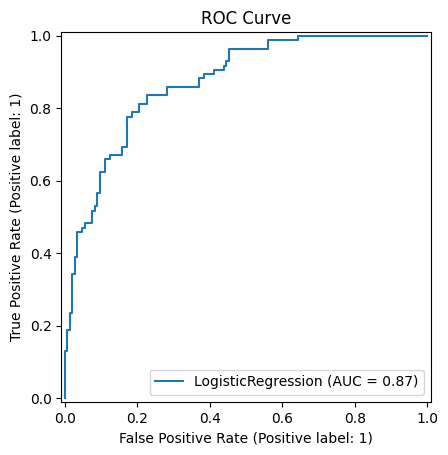

In [55]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_estimator(logreg, X_test, Y_test)
plt.title("ROC Curve")
plt.show()